# Text classification witn CNN

In [101]:
import requests
import tarfile
import pandas as pd
import os
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, Flatten, Dense, MaxPooling1D, Dropout
import gensim.downloader as api
from gensim.models import KeyedVectors

## Download dataset

In [24]:
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/review_polarity.tar.gz'
response = requests.get(url, stream=True)
file = tarfile.open(fileobj=response.raw, mode="r|gz")
file.extractall(path="dataset/")

## Tokenization

In [67]:
data = []
labels = {'pos': 1, 'neg': 0}

for sent in ('pos', 'neg'):
    base_path = os.path.join('dataset', 'txt_sentoken', sent)
    for file in os.listdir(base_path):
        with open(os.path.join(base_path, file), 'r', encoding='utf-8') as f:
            text = f.read()
        text = text.lower()
        data.append([text, labels[sent]])

df = pd.DataFrame(data, columns=['text', 'label'])
df['word_count'] = df['text'].apply(lambda x: len(x.split()))
max_len = df['word_count'].max()

In [68]:
df.head()

,text,label,word_count
0,films adapted from comic books have had plenty...,1,802
1,every now and then a movie comes along from a ...,1,769
2,you've got mail works alot better than it dese...,1,465
3,""" jaws "" is a rare film that grabs your atten...",1,1178
4,moviemaking is a lot like being the general ma...,1,748


In [69]:
df.describe()

,label,word_count
count,2000.000000,2000.00000
mean,0.500000,746.34050
std,0.500125,328.42529
min,0.000000,17.00000
25%,0.000000,526.75000
50%,0.500000,696.50000
75%,1.000000,904.00000
max,1.000000,2678.00000


In [70]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   text        2000 non-null   str  
 1   label       2000 non-null   int64
 2   word_count  2000 non-null   int64
dtypes: int64(2), str(1)
memory usage: 47.0 KB


In [71]:
max_words = 10000
tokenizer = Tokenizer(num_words=max_words,          
                      oov_token='<OOV>')        
tokenizer.fit_on_texts(df['text'])              

sequences = tokenizer.texts_to_sequences(df['text'])

padded_sequences = pad_sequences(sequences, maxlen=max_len, padding='post')

## Make dataset

In [72]:
X = padded_sequences
y = np.array(df['label'])

In [73]:
indices = np.arange(len(X))
np.random.shuffle(indices)
X_shuffled = X[indices]
y_shuffled = y[indices]

In [74]:
X_train, X_test, y_train, y_test = train_test_split(X_shuffled, y_shuffled, train_size=0.8)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1600, 2678), (400, 2678), (1600,), (400,))

## Model

In [76]:
vocab_size = max_words

model = Sequential()
model.add(Embedding(vocab_size, 100, input_length=max_len))
model.add(Conv1D(32, 8, activation='relu'))
model.add(MaxPooling1D(2))
model.add(Flatten())
model.add(Dense(10, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='adam',              
              loss='binary_crossentropy',    
              metrics=['accuracy'])  
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [78]:
history = model.fit(X_train, y_train,
                    epochs=20,               
                    batch_size=32,           
                    validation_data=(X_test, y_test),  
                    verbose=1)    

Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.9956 - loss: 0.2490 - val_accuracy: 0.7825 - val_loss: 0.5659
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.9969 - loss: 0.2382 - val_accuracy: 0.8400 - val_loss: 0.4421
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.9956 - loss: 0.2292 - val_accuracy: 0.8075 - val_loss: 0.4932
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9975 - loss: 0.2198 - val_accuracy: 0.8525 - val_loss: 0.4333
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9975 - loss: 0.2119 - val_accuracy: 0.8425 - val_loss: 0.4418
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.9975 - loss: 0.2041 - val_accuracy: 0.8150 - val_loss: 0.4754
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.9975 - loss: 0.1970 - val_accuracy: 0.8150 - val_loss: 0.4732
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.9975 - loss: 0.1898 - val_accuracy: 0.8325 - v

## Pretrained embedding

In [92]:
import gzip
import shutil

input_path = "glove-wiki-gigaword-50.gz"
output_path = "./models/glove-wiki-gigaword-50.txt" 

os.makedirs(os.path.dirname(output_path), exist_ok=True)

with gzip.open(input_path, 'rb') as f_in:
    with open(output_path, 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out) 

In [95]:
#w2v_model = api.load("glove-wiki-gigaword-50")
word2vec_model = KeyedVectors.load_word2vec_format(output_path, binary=False)

In [97]:
MAX_NUM_WORDS = 20000       
MAX_SEQUENCE_LENGTH = 100   

tokenizer = Tokenizer(num_words=MAX_NUM_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(df['text'])

sequences = tokenizer.texts_to_sequences(df['text'])

X = pad_sequences(sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
y = df['label'].values

In [98]:
indices = np.arange(len(X))
np.random.shuffle(indices)
X_shuffled = X[indices]
y_shuffled = y[indices]
X_train, X_test, y_train, y_test = train_test_split(X_shuffled, y_shuffled, train_size=0.8)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1600, 100), (400, 100), (1600,), (400,))

In [99]:
embedding_dim = word2vec_model.vector_size 

vocab_size = min(len(tokenizer.word_index) + 1, MAX_NUM_WORDS)

embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in tokenizer.word_index.items():
    if i >= vocab_size:
        continue
    if word in word2vec_model:
        embedding_matrix[i] = word2vec_model[word]
    else:
        embedding_matrix[i] = np.random.normal(scale=0.01, size=(embedding_dim,))

In [102]:
model = Sequential()
model.add(Embedding(input_dim=vocab_size,
                    output_dim=embedding_dim,
                    weights=[embedding_matrix],
                    input_length=MAX_SEQUENCE_LENGTH,
                    trainable=False))   # заморозим GloVe, чтобы не испортить

model.add(Conv1D(filters=64, kernel_size=5, activation='relu'))
model.add(MaxPooling1D(pool_size=2))
model.add(Conv1D(filters=128, kernel_size=5, activation='relu'))
model.add(MaxPooling1D(pool_size=2))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

model.summary()

c:\python3.11\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,000,000 (3.81 MB)

In [104]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train, y_train,
                    epochs=10,
                    batch_size=32,
                    validation_data=(X_train, y_train),
                    verbose=1)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5138 - loss: 0.7132 - val_accuracy: 0.5131 - val_loss: 0.6867
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5450 - loss: 0.6875 - val_accuracy: 0.6419 - val_loss: 0.6671
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5888 - loss: 0.6642 - val_accuracy: 0.7444 - val_loss: 0.6194
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6538 - loss: 0.6280 - val_accuracy: 0.7581 - val_loss: 0.5533
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7175 - loss: 0.5683 - val_accuracy: 0.9331 - val_loss: 0.4128
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8319 - loss: 0.4270 - val_accuracy: 0.9406 - val_loss: 0.2601
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9131 - loss: 0.2668 - val_accuracy: 0.9925 - val_loss: 0.0920
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9600 - loss: 0.1409 - val_accuracy: 0.9994 - val_loss:

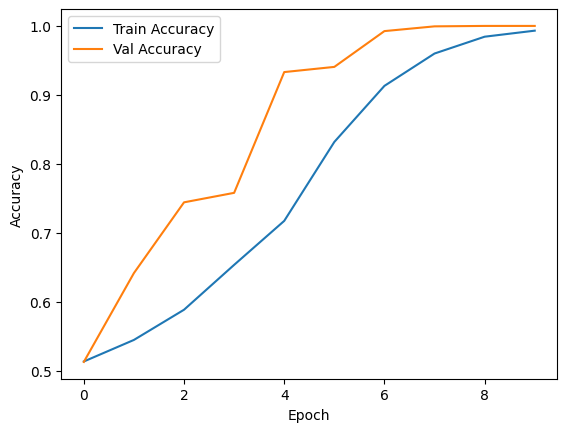

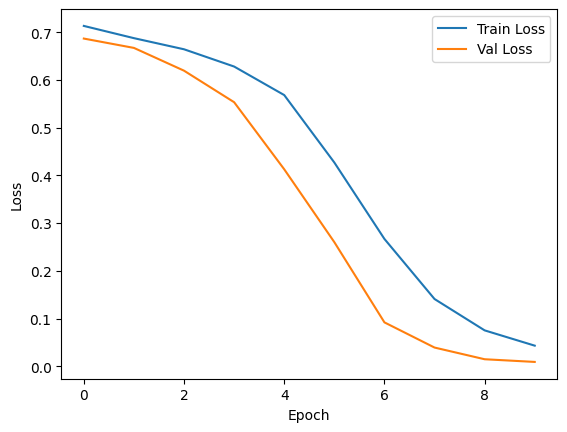

Validation Accuracy: 1.0000


In [105]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

loss, acc = model.evaluate(X_train, y_train, verbose=0)
print(f'Validation Accuracy: {acc:.4f}')